# **5장 : 회귀**
# **5.8 회귀 트리**

MSE : Mean Squared Error, 평균 제곱 오차  
RMSE : Root Mean Squared Error, 평균 제곱근 오차  
neg_MSE : Negative Mean Squared Error  
sklearn.model_selection.cross_val_score()는 기본적으로 값이 크면 좋은 성능이라고 간주함  
그런데 MSE는 작을수록 좋음  
따라서 사이킷런은 MSE를 그대로 쓰지 않고 부호를 바꿔서 -MSE로 반환함  

## RandomForestRegressor로 보스턴 주택 가격 예측

In [1]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

boston = pd.read_csv('BostonHousing.csv')
bostonDF = boston.copy()

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace = False)

rf = RandomForestRegressor(random_state=0, n_estimators=1000) # n_estimators=1000: 1000개의 결정 트리 사용
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring="neg_mean_squared_error",cv=5) # 5-폴드 교차검증으로 성능 평가
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5 교차 검증의 개별 Negative MSE Scores: ', np.round(neg_mse_scores,2))
print('5 교차 검증의 개별 RMSE Scores: ', np.round(rmse_scores,2))
print('5 교차 검증의 평균 RMSE: {0:.3f}'.format(avg_rmse))

5 교차 검증의 개별 Negative MSE Scores:  [ -7.88 -13.14 -20.57 -46.23 -18.88]
5 교차 검증의 개별 RMSE Scores:  [2.81 3.63 4.54 6.8  4.34]
5 교차 검증의 평균 RMSE: 4.423


## 다양한 유형의 회귀 트리를 이용해 보스턴 주택 가격 예측

In [2]:
def get_model_cv_prediction(model, X_data, y_target):
    neg_mse_scores = cross_val_score(model, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
    rmse_scores = np.sqrt(-1*neg_mse_scores)
    avg_rmse = np.mean(rmse_scores)
    print('##### ', model.__class__.__name__, ' #####')
    print('5교차 검증의 평균 RMSE : {0:.3f}\n\n'.format(avg_rmse))

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg=DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg=RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg=GradientBoostingRegressor(random_state=0, n_estimators=1000)
xgb_reg=XGBRegressor(n_estimators=1000)
lgb_reg=LGBMRegressor(n_estimators=1000)

models=[dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]
for model in models: 
    get_model_cv_prediction(model, X_data, y_target)

#####  DecisionTreeRegressor  #####
5교차 검증의 평균 RMSE : 5.978


#####  RandomForestRegressor  #####
5교차 검증의 평균 RMSE : 4.423


#####  GradientBoostingRegressor  #####
5교차 검증의 평균 RMSE : 4.269


#####  XGBRegressor  #####
5교차 검증의 평균 RMSE : 4.959


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000960 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 404, number of used features: 13
[LightGBM] [Info] Start training from score 22.566089
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

## features_importances_를 이용한 보스턴 주택 가격 모델의 피처별 중도도

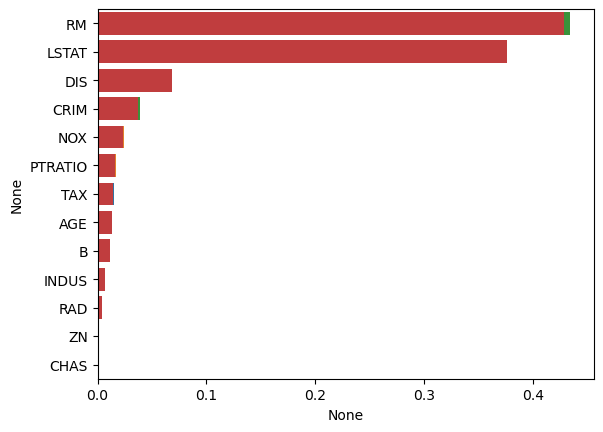

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

rf_reg = RandomForestRegressor(n_estimators=1000)

# 앞 예제에서 만들어진 X_data, y_target 데이터 세트를 적용해 학습
rf_reg.fit(X_data,y_target)

feature_series = pd.Series(data=rf_reg.feature_importances_,index=X_data.columns)
feature_series = feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series,y=feature_series.index)
plt.show()

## Price와 가장 밀접한 양의 상관관계를 가지는 RM 열만 추출해 Price 예측 회귀선 표시

(100, 2)


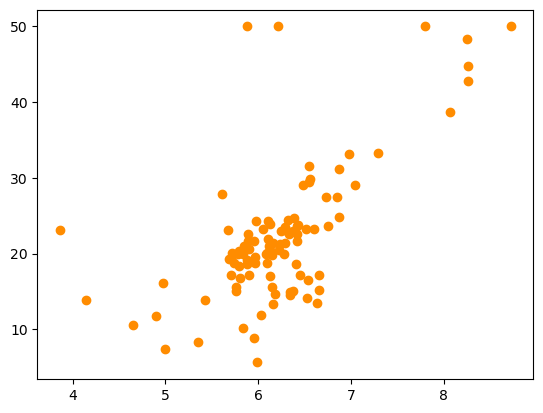

In [9]:
bostonDF_sample=bostonDF[['RM','PRICE']]
bostonDF_sample=bostonDF_sample.sample(n=100,random_state=0)
print(bostonDF_sample.shape)
plt.figure()
plt.scatter(bostonDF_sample.RM , bostonDF_sample.PRICE,c="darkorange")
plt.show()

## LinearRegression과 DecisionTreeRegressor를 max_depth=2,7로 해서 학습
### 이렇게 학습된 Regressor에 RM값을 4.5~8.5로 집어넣었을때의 예측값 구하기

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 선형 회귀와 결정 트리 기반의 Regressor 생성. DecisionTreeRegressor의 max_depth는 각각 2,7
lr_reg=LinearRegression()
rf_reg2=DecisionTreeRegressor(max_depth=2)
rf_reg7=DecisionTreeRegressor(max_depth=7)

# 실제 예측을 적용할 테스트용 데이터 세트를 4.5~8.5까지의 100개 데이터 세트로 생성
X_test=np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# RM, Price 추출
X_feature=bostonDF_sample['RM'].values.reshape(-1,1)
y_target=bostonDF_sample['PRICE'].values.reshape(-1,1)

# 학습, 예측
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_rf2 = rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

## 회귀선 그리기

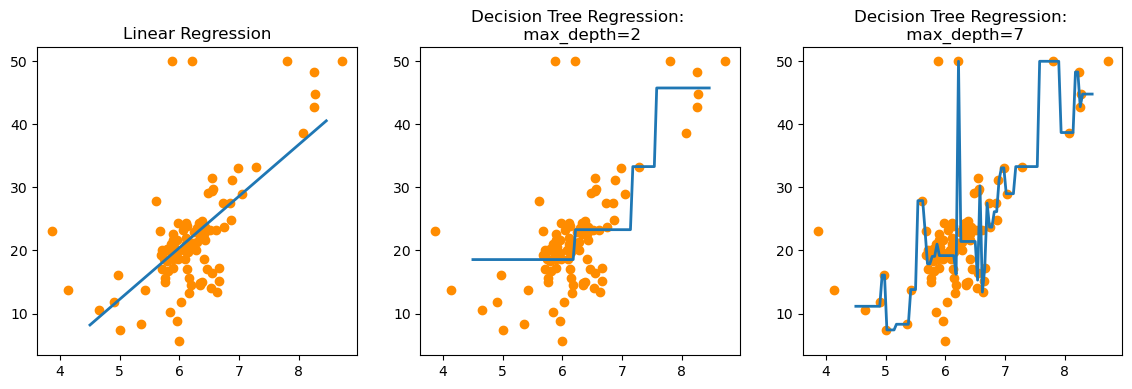

In [12]:
fig , (ax1, ax2, ax3) = plt.subplots(figsize=(14,4), ncols=3)

# x축 값을 4.5~8.5로 변환하며 입력했을 때 선형 회귀와 결정 트리 회귀 예측선 시각화
# 선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr,label="linear", linewidth=2 )

ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label="max_depth:3", linewidth=2 )

ax3.set_title('Decision Tree Regression: \n max_depth=7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax3.plot(X_test, pred_rf7, label="max_depth:7", linewidth=2)

plt.show()